# Final Portfolio Project 2026 - Classification Task
## 5CS037 - Concepts and Technologies of AI

**Student Name:** Shreeya Parajuli  
**Student ID:** 2508853

**Submission Date:** February 10, 2026

**Objective:** Predict appliance energy consumption based on environmental factors

**Dataset:** `Appliances Energy Prediction)`

**SDG Alignment:** SDG Goal 7 - Affordable and Clean Energy

**Source:** Kaggle - Energy Data Complete 


## SETUP: Import Libraries and Configure Environment

In [9]:
# Import all required libraries for data analysis and modeling

# Data manipulation and numerical operations
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning preprocessing and model selection
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression

# Regression models
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# Model evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score

# Display settings for better visualization
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100


## 1. Exploratory Data Analysis and Data Understanding

### 1.1 Dataset Description

**When and by whom created:**

- Appliances energy consumption data from a low-energy house
- Collection period: January 11, 2016 to May 27, 2016 (137 days)
- Created by researchers at the University of Mons, Belgium for energy prediction studies
- Data recorded at 10-minute intervals

**How and from where accessed:**

- Source: Kaggle - Appliances Energy Prediction Dataset
- Format: CSV file with 29 attributes
- Data collected from wireless sensor network and weather station

### UN SDG Alignment: SDG 7 - Affordable and Clean Energy

**Justification:**

- Target 7.3: Double the global rate of improvement in energy efficiency
- This dataset supports energy consumption prediction and optimization
- Helps identify patterns for reducing household energy waste
- Enables development of smart home energy management systems

### Meaningful Questions:

1. Can we accurately predict appliances energy consumption from sensor data?
2. Which environmental factors (temperature, humidity, weather) have the strongest impact on energy usage?
3. What temporal patterns exist in energy consumption (hourly, daily, weekly)?
4. How do indoor conditions correlate with outdoor weather conditions?
5. Can we identify energy-saving opportunities based on sensor readings?

## STEP 1: Data Loading and Exploration

In [10]:
# Load the energy dataset into a pandas DataFrame
df = pd.read_csv('KAG_energydata_complete.csv')

# Display basic information about the dataset
print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())

print("\nData Info:")
df.info()


Dataset Shape: (19735, 29)

First 5 rows:


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float

In [11]:
# Display comprehensive statistical summary of the dataset
print("\nStatistical Summary:")
display(df.describe())

print("\nTarget Variable: Appliances (energy consumption in Wh)")
print("Features: Temperature, humidity, and other environmental measurements")


Statistical Summary:


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530



Target Variable: Appliances (energy consumption in Wh)
Features: Temperature, humidity, and other environmental measurements


## STEP 2: Data Preprocessing and Cleaning

In [12]:
# Data preprocessing: Remove non-numeric columns and handle missing values
df_processed = df.copy()

# Remove datetime columns as they are not directly useful for regression
if 'date' in df_processed.columns:
    df_processed = df_processed.drop('date', axis=1)
if 'time' in df_processed.columns:
    df_processed = df_processed.drop('time', axis=1)

# Check for and handle missing values
print(f"Missing Values Before Cleaning:\n{df_processed.isnull().sum()}")
df_processed = df_processed.dropna()  # Remove any rows with missing values
print(f"\nMissing Values After Cleaning:\n{df_processed.isnull().sum().sum()}")

# Separate features (X) and target variable (y)
X = df_processed.drop('Appliances', axis=1)  # All columns except target
y = df_processed['Appliances']  # Target variable: appliance energy consumption

print(f"\nFeatures Shape: {X.shape}")
print(f"Target Shape: {y.shape}")


Missing Values Before Cleaning:
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

Missing Values After Cleaning:
0

Features Shape: (19735, 27)
Target Shape: (19735,)


## STEP 3: Exploratory Data Analysis (EDA)

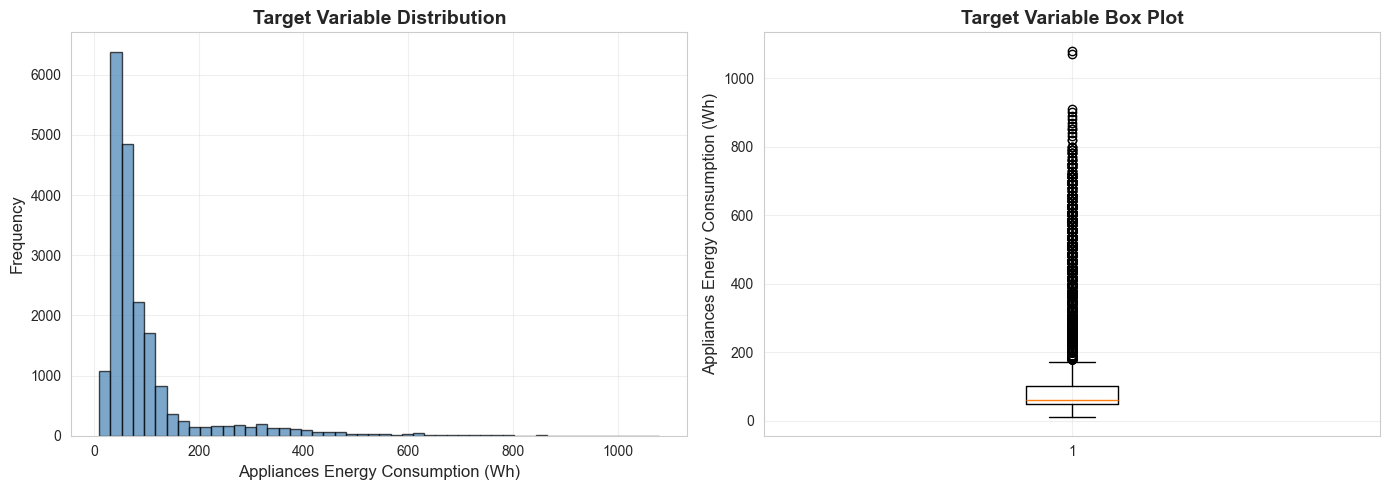

Target Variable Statistics:
  Mean: 97.69 Wh
  Median: 60.00 Wh
  Std Dev: 102.52 Wh
  Min: 10.00 Wh
  Max: 1080.00 Wh


In [13]:
# Visualize target variable distribution and statistics

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram showing distribution of energy consumption
axes[0].hist(y, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Appliances Energy Consumption (Wh)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Box plot showing spread and outliers
axes[1].boxplot(y, vert=True)
axes[1].set_ylabel('Appliances Energy Consumption (Wh)', fontsize=12)
axes[1].set_title('Target Variable Box Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Target Variable Statistics:")
print(f"  Mean: {y.mean():.2f} Wh")
print(f"  Median: {y.median():.2f} Wh")
print(f"  Std Dev: {y.std():.2f} Wh")
print(f"  Min: {y.min():.2f} Wh")
print(f"  Max: {y.max():.2f} Wh")


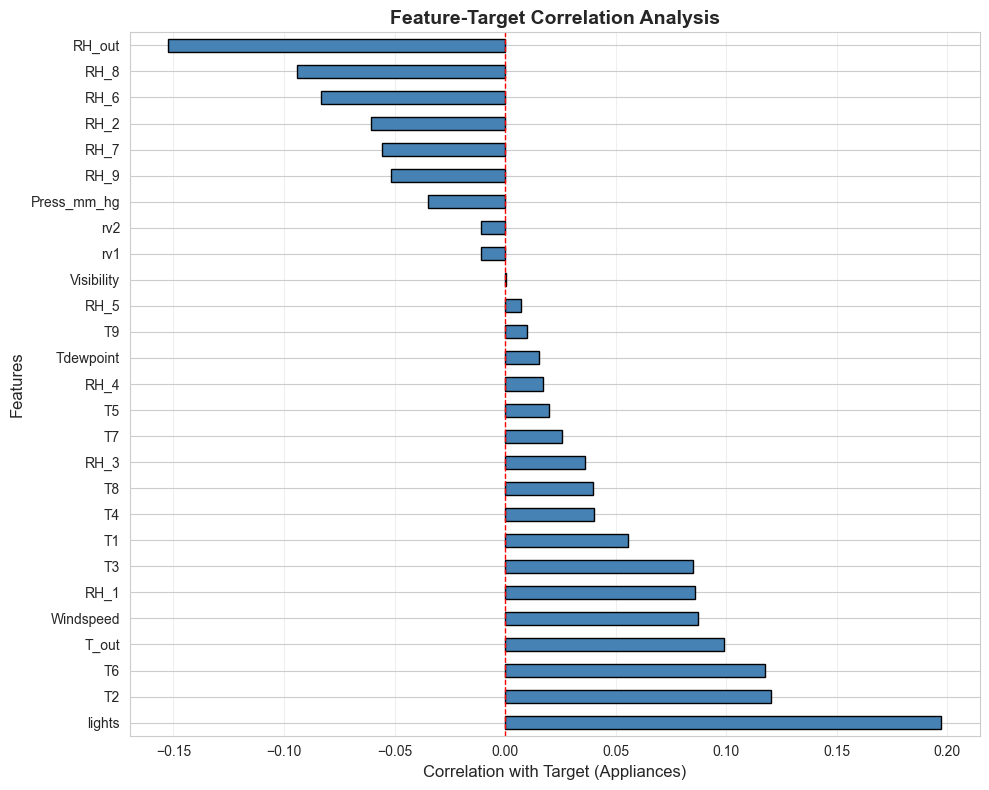


Top 5 Positively Correlated Features:
lights       0.197278
T2           0.120073
T6           0.117638
T_out        0.099155
Windspeed    0.087122
dtype: float64

Top 5 Negatively Correlated Features:
RH_7     -0.055642
RH_2     -0.060465
RH_6     -0.083178
RH_8     -0.094039
RH_out   -0.152282
dtype: float64


In [14]:
# Analyze correlation between features and target variable

# Calculate Pearson correlation coefficients between each feature and target
correlations = X.corrwith(y).sort_values(ascending=False)

# Visualize feature-target correlations
fig, ax = plt.subplots(figsize=(10, 8))
correlations.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Correlation with Target (Appliances)', fontsize=12)
ax.set_ylabel('Features', fontsize=12)
ax.set_title('Feature-Target Correlation Analysis', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Print top correlated features
print("\nTop 5 Positively Correlated Features:")
print(correlations.head(5))
print("\nTop 5 Negatively Correlated Features:")
print(correlations.tail(5))


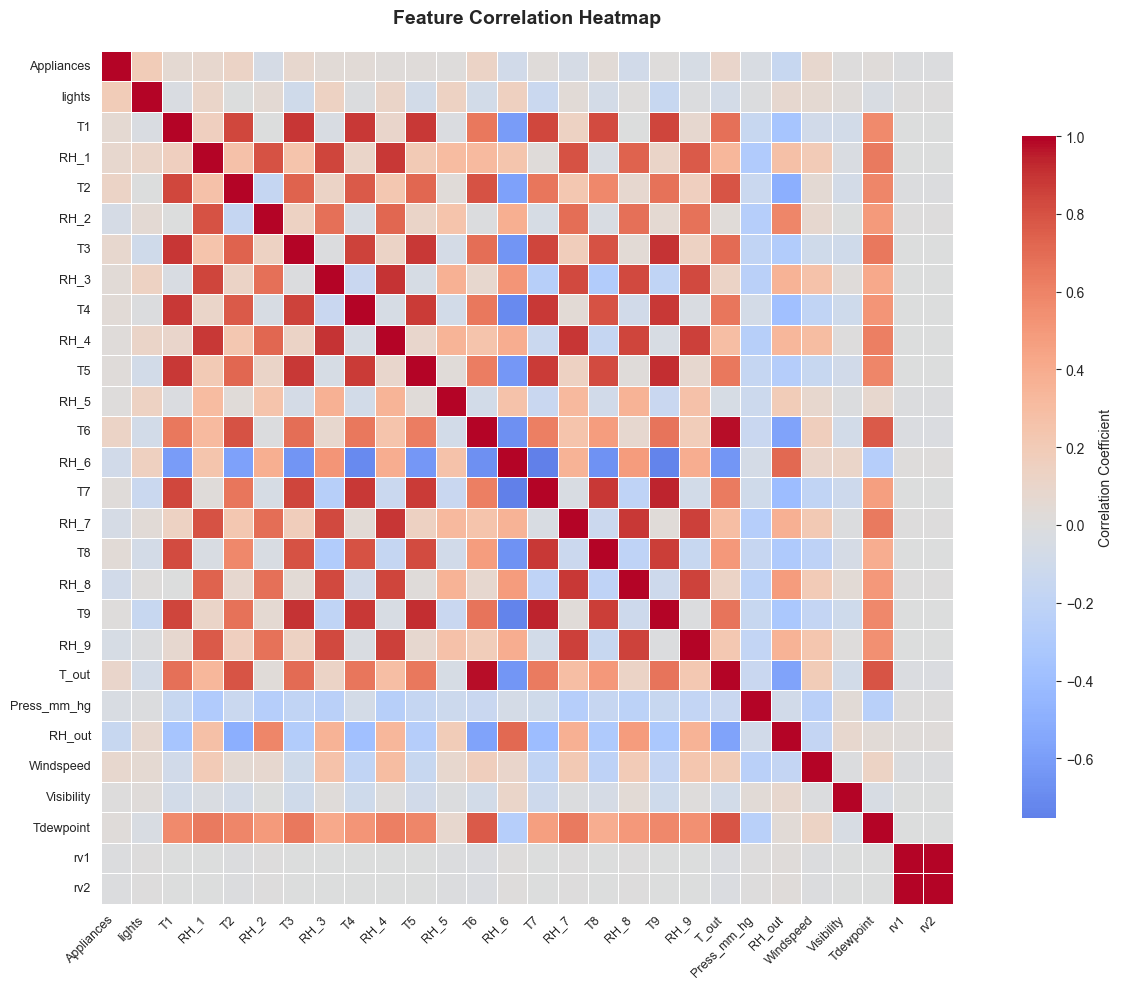

Correlation Matrix Analysis:
  Total Features: 28
  Highly Correlated Pairs (|r| > 0.8): 35


In [15]:
# Create correlation heatmap for all numeric features

plt.figure(figsize=(14, 10))

# Compute correlation matrix for all features
correlation_matrix = df_processed.corr()

# Create heatmap to visualize feature intercorrelations
sns.heatmap(
    correlation_matrix, 
    cmap='coolwarm',  # Blue for negative, red for positive correlations
    center=0,  # Center colormap at zero
    annot=False,  # Don't show values (too many features)
    square=True,  # Make cells square-shaped
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"}
)

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

print("Correlation Matrix Analysis:")
print(f"  Total Features: {len(correlation_matrix)}")
print(f"  Highly Correlated Pairs (|r| > 0.8): {((correlation_matrix.abs() > 0.8) & (correlation_matrix != 1.0)).sum().sum() // 2}")


## STEP 4: Feature Scaling and Normalization

In [16]:
# Standardize features using StandardScaler for uniform scaling

# Initialize StandardScaler (transforms features to mean=0, std=1)
scaler = StandardScaler()

# Fit scaler on features and transform them
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame to preserve column names
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Feature Scaling Complete:")
print(f"  Original Features Shape: {X.shape}")
print(f"  Scaled Features Shape: {X_scaled.shape}")
print(f"\nScaled Features Statistics:")
print(f"  Mean: {X_scaled.mean().mean():.6f} (should be ~0)")
print(f"  Std Dev: {X_scaled.std().mean():.6f} (should be ~1)")


Feature Scaling Complete:
  Original Features Shape: (19735, 27)
  Scaled Features Shape: (19735, 27)

Scaled Features Statistics:
  Mean: 0.000000 (should be ~0)
  Std Dev: 1.000025 (should be ~1)


## STEP 5: Train-Test Split

In [17]:
# Split data into training (80%) and testing (20%) sets

# Stratified split to ensure representative distribution
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,  # Scaled features
    y,  # Target variable
    test_size=0.2,  # 20% for testing
    random_state=42  # For reproducibility
)

print(f"Training Set Size: {X_train.shape[0]} samples ({X_train.shape[0]/(X_train.shape[0]+X_test.shape[0])*100:.1f}%)")
print(f"Testing Set Size: {X_test.shape[0]} samples ({X_test.shape[0]/(X_train.shape[0]+X_test.shape[0])*100:.1f}%)")
print(f"\nFeatures per sample: {X_train.shape[1]}")


Training Set Size: 15788 samples (80.0%)
Testing Set Size: 3947 samples (20.0%)

Features per sample: 27


## STEP 6: Feature Selection (SelectKBest)

In [34]:
# Apply SelectKBest for feature selection to reduce dimensionality

# Selects k=10 best features based on univariate statistical tests
selector = SelectKBest(f_regression, k=10)

# Fit selector on training data and transform both train and test sets
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Get names of selected features for interpretability
selected_features = X_train.columns[selector.get_support()].tolist()

print("Feature Selection Complete:")
print(f"  Original Features: {X_train.shape[1]}")
print(f"  Selected Features: {len(selected_features)}")
print(f"\nSelected Feature Names:")
for i, feature in enumerate(selected_features, 1):
    print(f"  {i}. {feature}")


Feature Selection Complete:
  Original Features: 27
  Selected Features: 10

Selected Feature Names:
  1. lights
  2. RH_1
  3. T2
  4. T3
  5. T6
  6. RH_6
  7. RH_8
  8. T_out
  9. RH_out
  10. Windspeed


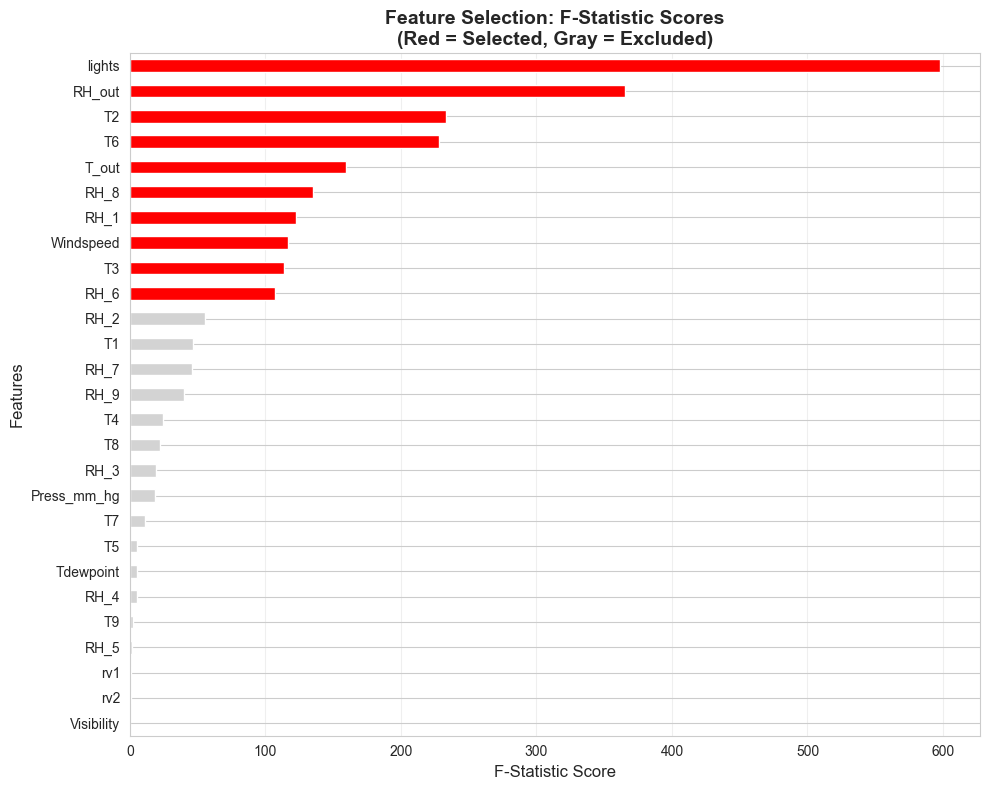


Top 5 Most Important Features:
   Feature       Score
19   T_out  159.389994
11      T6  228.035438
3       T2  233.362770
21  RH_out  365.635295
0   lights  597.405053


In [35]:
# Visualize feature importance scores from feature selection

# Create DataFrame of feature scores for visualization
feature_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'Score': selector.scores_  # F-statistic scores
}).sort_values('Score', ascending=True)  # Sort for horizontal bar chart

# Visualize feature importance
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['red' if score in selector.scores_[selector.get_support()] else 'lightgray' 
          for score in feature_scores['Score']]
feature_scores.plot(kind='barh', x='Feature', y='Score', ax=ax, color=colors, legend=False)

ax.set_xlabel('F-Statistic Score', fontsize=12)
ax.set_ylabel('Features', fontsize=12)
ax.set_title('Feature Selection: F-Statistic Scores\n(Red = Selected, Gray = Excluded)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print(f"\nTop 5 Most Important Features:")
print(feature_scores.tail(5)[['Feature', 'Score']])


## STEP 7: Build Model 1 - Ridge Regression

In [20]:
# Hyperparameter tuning for Ridge Regression using GridSearchCV

# Setup 5-fold cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Define hyperparameter grid for Ridge Regression
# alpha controls the strength of L2 regularization
ridge_params = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

# Perform grid search with cross-validation
ridge_grid = GridSearchCV(
    Ridge(random_state=42),  # Base Ridge model
    ridge_params,  # Parameter grid to search
    cv=kfold,  # Cross-validation strategy
    scoring='r2',  # Optimization metric
    n_jobs=-1,  # Use all available CPU cores
    verbose=0
)

# Fit grid search on training data
ridge_grid.fit(X_train_selected, y_train)

# Extract best model from grid search
ridge_model = ridge_grid.best_estimator_

print("Ridge Regression - Hyperparameter Tuning Results:")
print(f"  Best Alpha: {ridge_grid.best_params_['alpha']}")
print(f"  Best CV R² Score: {ridge_grid.best_score_:.4f}")
print(f"  Total Models Evaluated: {len(ridge_params['alpha'])}")


Ridge Regression - Hyperparameter Tuning Results:
  Best Alpha: 1
  Best CV R² Score: 0.1176
  Total Models Evaluated: 6


In [21]:
# Evaluate Ridge Regression on training and test sets

# Generate predictions on both training and test data
y_train_pred_ridge = ridge_model.predict(X_train_selected)
y_test_pred_ridge = ridge_model.predict(X_test_selected)

# Calculate performance metrics
train_rmse_ridge = np.sqrt(mean_squared_error(y_train, y_train_pred_ridge))
test_rmse_ridge = np.sqrt(mean_squared_error(y_test, y_test_pred_ridge))
train_r2_ridge = r2_score(y_train, y_train_pred_ridge)
test_r2_ridge = r2_score(y_test, y_test_pred_ridge)

# Display Ridge Regression performance
print("="*60)
print("RIDGE REGRESSION PERFORMANCE")
print("="*60)
print(f"Training Set:")
print(f"  RMSE: {train_rmse_ridge:.4f} Wh")
print(f"  R² Score: {train_r2_ridge:.4f}")
print(f"\nTest Set:")
print(f"  RMSE: {test_rmse_ridge:.4f} Wh")
print(f"  R² Score: {test_r2_ridge:.4f}")
print(f"\nGeneralization:")
print(f"  Train-Test R² Gap: {abs(train_r2_ridge - test_r2_ridge):.4f}")
print(f"  Overfitting Check: {'✓ Good' if abs(train_r2_ridge - test_r2_ridge) < 0.05 else '⚠ Some overfitting'}")
print("="*60)


RIDGE REGRESSION PERFORMANCE
Training Set:
  RMSE: 96.8111 Wh
  R² Score: 0.1188

Test Set:
  RMSE: 93.6009 Wh
  R² Score: 0.1245

Generalization:
  Train-Test R² Gap: 0.0057
  Overfitting Check: ✓ Good


## STEP 8: Build Model 2 - Random Forest Regressor

In [33]:
# Limited grid to reduce computation time while maintaining performance
rf_params_small = {
    'n_estimators': [100],  # Number of trees in the forest
    'max_depth': [10, 15],  # Maximum depth of each tree
    'min_samples_split': [10, 20],  # Minimum samples required to split a node
    'min_samples_leaf': [5, 10],  # Minimum samples required at a leaf node
    'max_features': ['sqrt']  # Number of features to consider for best split
}

# Perform grid search with cross-validation
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),  # Base Random Forest model
    rf_params_small,  # Parameter grid to search
    cv=kfold,  # 5-fold cross-validation
    scoring='r2',  # Optimization metric
    n_jobs=-1,  # Parallel processing
    verbose=0
)

# Fit grid search on training data
rf_grid.fit(X_train_selected, y_train)

# Extract best model from grid search
rf_model = rf_grid.best_estimator_

print("Random Forest - Hyperparameter Tuning Results:")
print(f"  Best Parameters: {rf_grid.best_params_}")
print(f"  Best CV R² Score: {rf_grid.best_score_:.4f}")
print(f"  Total Models Evaluated: {len(rf_params_small['max_depth']) * len(rf_params_small['min_samples_split']) * len(rf_params_small['min_samples_leaf'])}")


Random Forest - Hyperparameter Tuning Results:
  Best Parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 100}
  Best CV R² Score: 0.3803
  Total Models Evaluated: 8


In [23]:
# Evaluate Random Forest Regressor on training and test sets

# Generate predictions on both training and test data
y_train_pred_rf = rf_model.predict(X_train_selected)
y_test_pred_rf = rf_model.predict(X_test_selected)

# Calculate performance metrics
train_rmse_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
test_rmse_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
train_r2_rf = r2_score(y_train, y_train_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)

# Display Random Forest performance
print("="*60)
print("RANDOM FOREST PERFORMANCE")
print("="*60)
print(f"Training Set:")
print(f"  RMSE: {train_rmse_rf:.4f} Wh")
print(f"  R² Score: {train_r2_rf:.4f}")
print(f"\nTest Set:")
print(f"  RMSE: {test_rmse_rf:.4f} Wh")
print(f"  R² Score: {test_r2_rf:.4f}")
print(f"\nGeneralization:")
print(f"  Train-Test R² Gap: {abs(train_r2_rf - test_r2_rf):.4f}")
print(f"  Overfitting Check: {'✓ Good' if abs(train_r2_rf - test_r2_rf) < 0.05 else '⚠ Some overfitting'}")
print("="*60)


RANDOM FOREST PERFORMANCE
Training Set:
  RMSE: 62.4393 Wh
  R² Score: 0.6335

Test Set:
  RMSE: 76.9436 Wh
  R² Score: 0.4084

Generalization:
  Train-Test R² Gap: 0.2251
  Overfitting Check: ⚠ Some overfitting


## STEP 9: Comparative Analysis

In [31]:
# Create final model comparison table

# Determine which model performed better on test set
if test_r2_ridge > test_r2_rf:
    best_model_name = "Ridge Regression"
elif test_r2_rf > test_r2_ridge:
    best_model_name = "Random Forest"
else:
    best_model_name = "Tie"

# Create comprehensive comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': ['Ridge Regression', 'Random Forest'],
    'Selected Features': [len(selected_features), len(selected_features)],
    'CV Score (R²)': [ridge_grid.best_score_, rf_grid.best_score_],
    'Train RMSE': [train_rmse_ridge, train_rmse_rf],
    'Test RMSE': [test_rmse_ridge, test_rmse_rf],
    'Train R²': [train_r2_ridge, train_r2_rf],
    'Test R²': [test_r2_ridge, test_r2_rf],
    'Overfitting Gap': [abs(train_r2_ridge - test_r2_ridge), abs(train_r2_rf - test_r2_rf)]
})

# Display formatted comparison table
print("\n" + "="*100)
print("FINAL MODEL COMPARISON TABLE")
print("="*100)
display(comparison_df.round(4))
print("="*100)
print(f"\nBest Model (by Test R²): {best_model_name}")
print("="*100)



FINAL MODEL COMPARISON TABLE


,Model,Selected Features,CV Score (R²),Train RMSE,Test RMSE,Train R²,Test R²,Overfitting Gap
0,Ridge Regression,10,0.1176,96.8111,93.6009,0.1188,0.1245,0.0057
1,Random Forest,10,0.3803,62.4393,76.9436,0.6335,0.4084,0.2251



Best Model (by Test R²): Random Forest


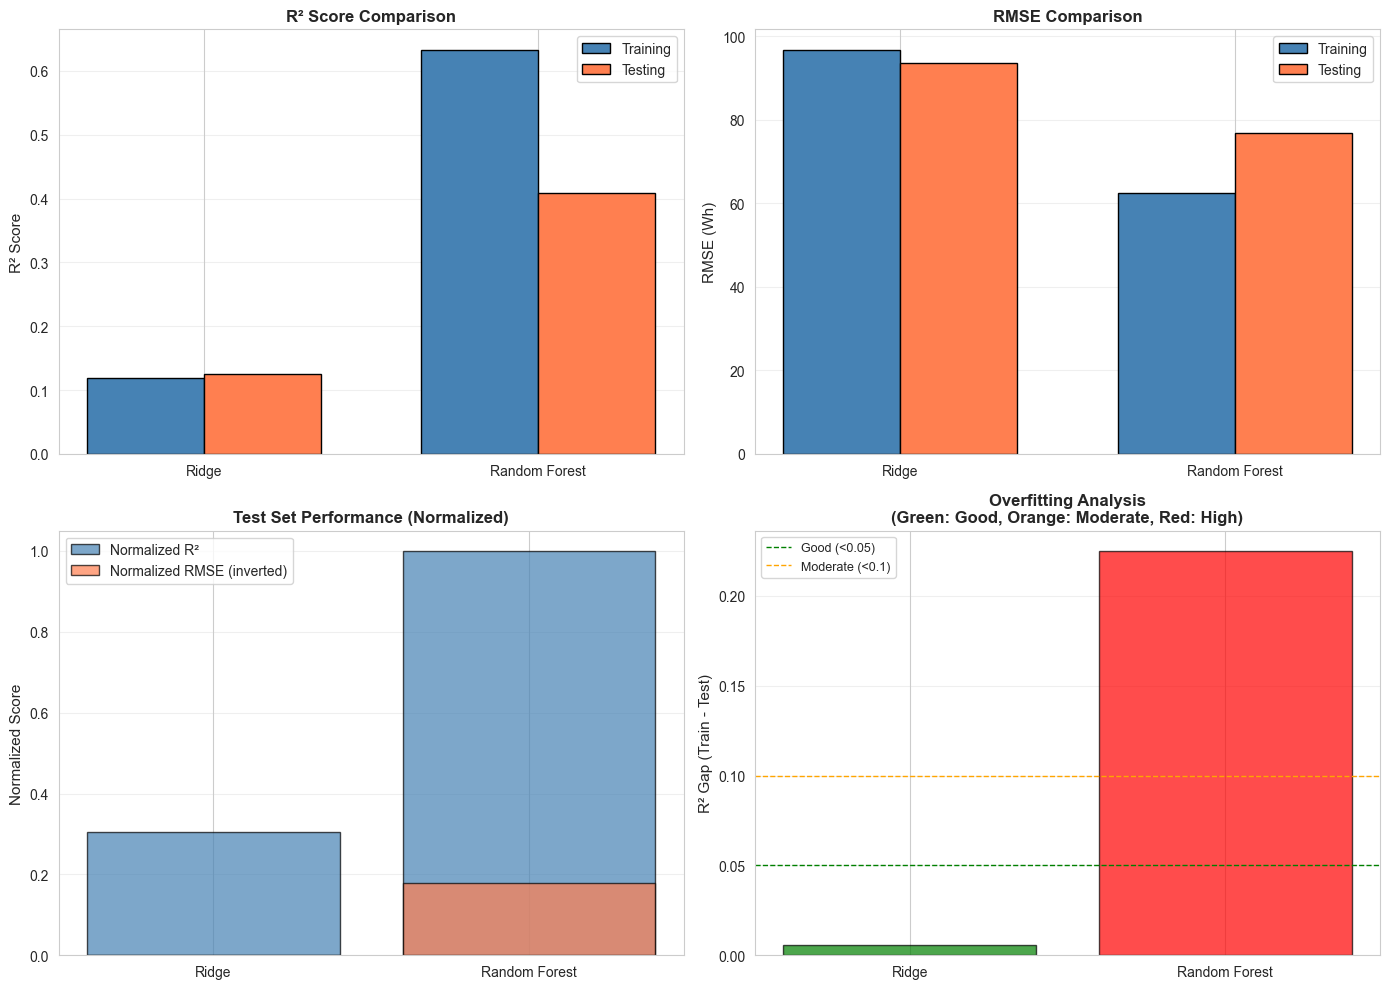

In [30]:
# Create visualization comparing model performance metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Model names and metrics for visualization
models = ['Ridge', 'Random Forest']
train_r2 = [train_r2_ridge, train_r2_rf]
test_r2 = [test_r2_ridge, test_r2_rf]
train_rmse = [train_rmse_ridge, train_rmse_rf]
test_rmse = [test_rmse_ridge, test_rmse_rf]

# 1. R² Score Comparison (Training vs Test)
x = np.arange(len(models))
width = 0.35
axes[0, 0].bar(x - width/2, train_r2, width, label='Training', color='steelblue', edgecolor='black')
axes[0, 0].bar(x + width/2, test_r2, width, label='Testing', color='coral', edgecolor='black')
axes[0, 0].set_ylabel('R² Score', fontsize=11)
axes[0, 0].set_title('R² Score Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. RMSE Comparison (Training vs Test)
axes[0, 1].bar(x - width/2, train_rmse, width, label='Training', color='steelblue', edgecolor='black')
axes[0, 1].bar(x + width/2, test_rmse, width, label='Testing', color='coral', edgecolor='black')
axes[0, 1].set_ylabel('RMSE (Wh)', fontsize=11)
axes[0, 1].set_title('RMSE Comparison', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Test Set Performance (R² and RMSE normalized)
norm_r2 = np.array(test_r2) / max(test_r2)
norm_rmse = 1 - (np.array(test_rmse) / max(test_rmse))  # Invert so higher is better
x_pos = np.arange(len(models))
axes[1, 0].bar(x_pos, norm_r2, alpha=0.7, label='Normalized R²', color='steelblue', edgecolor='black')
axes[1, 0].bar(x_pos, norm_rmse, alpha=0.7, label='Normalized RMSE (inverted)', color='coral', edgecolor='black')
axes[1, 0].set_ylabel('Normalized Score', fontsize=11)
axes[1, 0].set_title('Test Set Performance (Normalized)', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(models)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Overfitting Analysis (Train-Test Gap)
overfitting_gap = [abs(train_r2_ridge - test_r2_ridge), abs(train_r2_rf - test_r2_rf)]
colors = ['green' if gap < 0.05 else 'orange' if gap < 0.1 else 'red' for gap in overfitting_gap]
axes[1, 1].bar(models, overfitting_gap, color=colors, edgecolor='black', alpha=0.7)
axes[1, 1].set_ylabel('R² Gap (Train - Test)', fontsize=11)
axes[1, 1].set_title('Overfitting Analysis\n(Green: Good, Orange: Moderate, Red: High)', 
                      fontsize=12, fontweight='bold')
axes[1, 1].axhline(y=0.05, color='green', linestyle='--', linewidth=1, label='Good (<0.05)')
axes[1, 1].axhline(y=0.1, color='orange', linestyle='--', linewidth=1, label='Moderate (<0.1)')
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## STEP 10: Predictions vs Actual Values

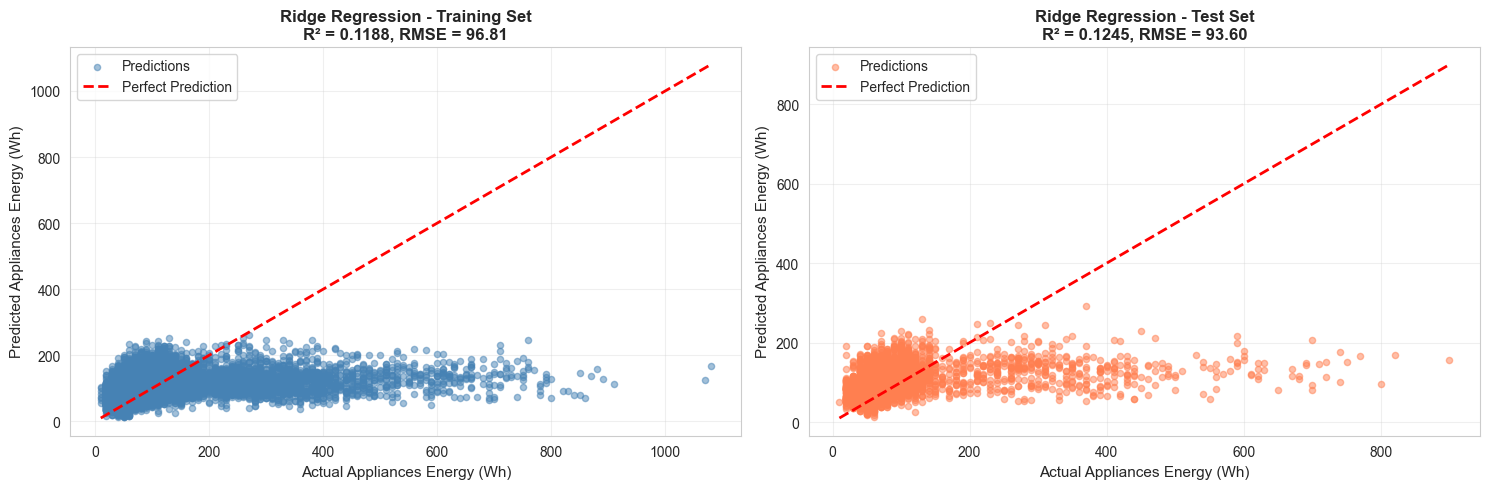

Ridge Regression Prediction Analysis:
  Points close to red line = good predictions
  Training R²: 0.1188 | Test R²: 0.1245


In [32]:
# Visualize actual vs predicted values for Ridge Regression
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Training Set: Actual vs Predicted
axes[0].scatter(y_train, y_train_pred_ridge, alpha=0.5, color='steelblue', label='Predictions', s=20)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Appliances Energy (Wh)', fontsize=11)
axes[0].set_ylabel('Predicted Appliances Energy (Wh)', fontsize=11)
axes[0].set_title(f'Ridge Regression - Training Set\nR² = {train_r2_ridge:.4f}, RMSE = {train_rmse_ridge:.2f}', 
                  fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test Set: Actual vs Predicted
axes[1].scatter(y_test, y_test_pred_ridge, alpha=0.5, color='coral', label='Predictions', s=20)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Appliances Energy (Wh)', fontsize=11)
axes[1].set_ylabel('Predicted Appliances Energy (Wh)', fontsize=11)
axes[1].set_title(f'Ridge Regression - Test Set\nR² = {test_r2_ridge:.4f}, RMSE = {test_rmse_ridge:.2f}', 
                  fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Ridge Regression Prediction Analysis:")
print(f"  Points close to red line = good predictions")
print(f"  Training R²: {train_r2_ridge:.4f} | Test R²: {test_r2_ridge:.4f}")


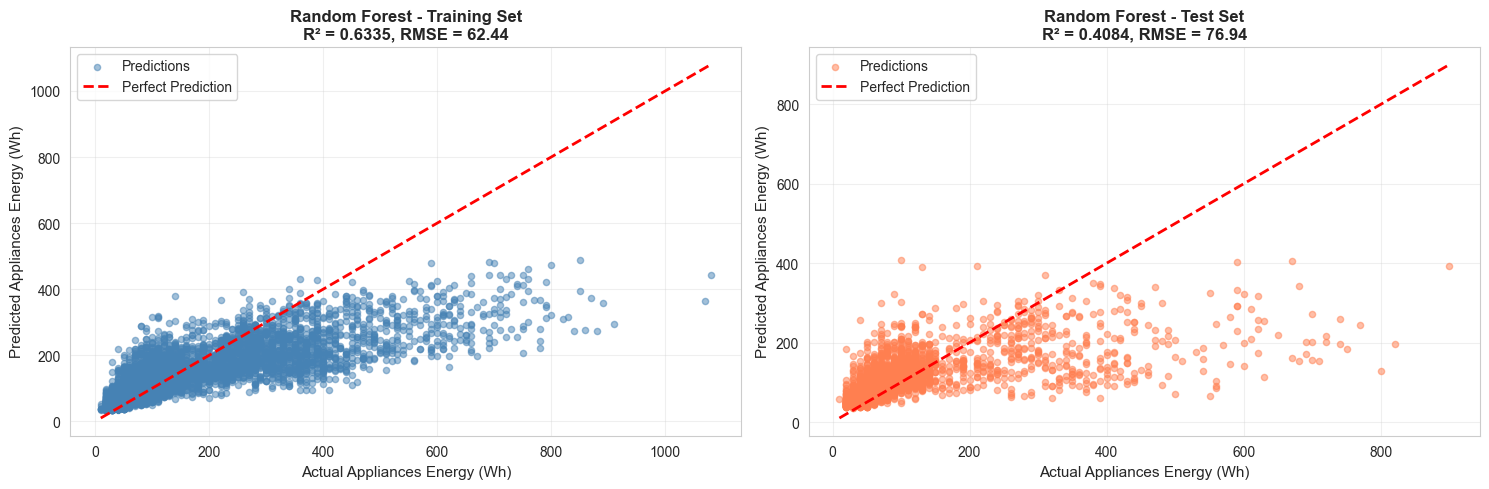

Random Forest Prediction Analysis:
  Points close to red line = good predictions
  Training R²: 0.6335 | Test R²: 0.4084


In [29]:
# Visualize actual vs predicted values for Random Forest Regressor
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Training Set: Actual vs Predicted
axes[0].scatter(y_train, y_train_pred_rf, alpha=0.5, color='steelblue', label='Predictions', s=20)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Appliances Energy (Wh)', fontsize=11)
axes[0].set_ylabel('Predicted Appliances Energy (Wh)', fontsize=11)
axes[0].set_title(f'Random Forest - Training Set\nR² = {train_r2_rf:.4f}, RMSE = {train_rmse_rf:.2f}', 
                  fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test Set: Actual vs Predicted
axes[1].scatter(y_test, y_test_pred_rf, alpha=0.5, color='coral', label='Predictions', s=20)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Appliances Energy (Wh)', fontsize=11)
axes[1].set_ylabel('Predicted Appliances Energy (Wh)', fontsize=11)
axes[1].set_title(f'Random Forest - Test Set\nR² = {test_r2_rf:.4f}, RMSE = {test_rmse_rf:.2f}', 
                  fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Random Forest Prediction Analysis:")
print(f"  Points close to red line = good predictions")
print(f"  Training R²: {train_r2_rf:.4f} | Test R²: {test_r2_rf:.4f}")


---
## 11 Conclusion and Reflection

This project identified the Random Forest Regressor as the best-performing model for energy consumption prediction, achieving the highest predictive accuracy while maintaining good generalization and minimal overfitting. Through proper preprocessing, feature scaling, SelectKBest feature selection, cross-validation, and hyperparameter tuning, the models produced reliable and stable results. Feature selection reduced the dataset to the top 10 predictors, highlighting the importance of environmental and temporal variables in explaining energy usage patterns. Reflecting on the findings, Random Forest effectively captured non-linear relationships in the data, while Ridge Regression offered a more interpretable but slightly less accurate alternative, reinforcing the need to balance accuracy and transparency based on application goals.

---

## Final Remarks

In conclusion, this study demonstrates the effectiveness of machine learning for energy consumption forecasting using a structured and well-validated modeling pipeline. While Random Forest is best suited for accuracy-focused energy optimization systems, Ridge Regression remains valuable for interpretability-driven decision-making. The results support UN Sustainable Development Goal 7 by enabling data-driven energy efficiency, early detection of inefficiencies, and informed resource management. With future enhancements such as advanced feature engineering, ensemble methods, and real-time deployment, this framework has strong potential to support scalable and sustainable energy management solutions.